# Introducción teórica

En esta practica se estudia la estimación de los parámetros de una señal sinusoidal en presencia de ruido aleatorio. La señal analizada está dada por

$$
x(n)=a_0\sin(\Omega_1 n)+n_a(n)
$$

donde a0 es la amplitud de la sinusoidal,  Omega_1  su frecuencia angular discreta y  na(n)  es un ruido blanco gaussiano de media nula y varianza  sigma^2 .

La amplitud utilizada es

$$
a_0=\sqrt{2},
$$

por lo que la potencia de la componente sinusoidal es

$$
P_s=\frac{a_0^2}{2}=1\;W.
$$

La frecuencia de la sinusoidal no es exactamente igual a la frecuencia central  Omega_0 , sino que se introduce una desintonía aleatoria:

$$
\Omega_1=\Omega_0+f_r\frac{2\pi}{N},
$$

con

$$
\Omega_0=\frac{\pi}{2},
\qquad
f_r\sim U(-2,2).
$$

De esta manera, la frecuencia de la señal puede encontrarse hasta dos intervalos de frecuencia  Deltaf = fs /N  por encima o por debajo de Omega_0. Para fs=1000 Hz y N=1000 muestras se obtiene

$$
\Delta f=\frac{f_s}{N}=1\;Hz,
$$

 

## Relación señal-ruido

La relación señal-ruido (SNR) se define como

$$
SNR=\frac{P_s}{P_n},
$$

o, expresada en decibelios,

$$
SNR_{dB}=10\log_{10}\left(\frac{P_s}{P_n}\right).
$$

Como Ps=1 W, la potencia del ruido utilizada en cada experimento es

$$
\sigma^2=P_n=\frac{1}{10^{SNR_{dB}/10}}.
$$

Por lo tanto, para  SNR=3  dB se obtiene sigma^2 approx0.5012 , mientras que para  SNR=10 dB se obtiene  sigma^2=0.1

## Análisis espectral y ventanas

Para estimar la amplitud y la frecuencia de la sinusoidal se analiza su transformada de Fourier después de aplicar diferentes ventanas temporales. Si \(w_i(n)\) representa una ventana, la señal ventaneada es

$$
x_w(n)=x(n)w_i(n)
$$

y su transformada de Fourier puede escribirse como

$$
X_{iw}(\Omega)=\mathcal{F}\{x(n)w_i(n)\}.
$$

El uso de una ventana modifica la forma del espectro. En particular, existe un compromiso entre el ancho del lóbulo principal y la atenuación de los lóbulos laterales. Por este motivo, distintas ventanas pueden producir diferentes resultados en la estimación de amplitud y frecuencia.

se comparan cuatro ventanas:

* **Rectangular**, que equivale a no aplicar una ventana.
* **Flat-top**, diseñada para obtener una elevada precisión en la estimación de amplitud.
* **Blackman-Harris**, que presenta una fuerte reducción de los lóbulos laterales.
* **Hann**, que proporciona un compromiso entre resolución espectral y reducción del leakage.

 

## Sesgo y varianza

Para evaluar la calidad de los estimadores se realizan \(200\) experimentos independientes para cada nivel de SNR y para cada ventana.

El **sesgo** de un estimador indica cuánto se aleja, en promedio, la estimación del valor verdadero. Para la amplitud se calcula como

$$
\operatorname{Sesgo}(\hat a)
=
\overline{\hat a}-a_0.
$$

La **varianza** mide la dispersión de las estimaciones alrededor de su valor medio:

$$
\operatorname{Var}(\hat a)
=
\frac{1}{M}
\sum_{j=1}^{M}
(\hat a_j-\overline{\hat a})^2,
$$

donde  M=200  es el número de realizaciones.

 

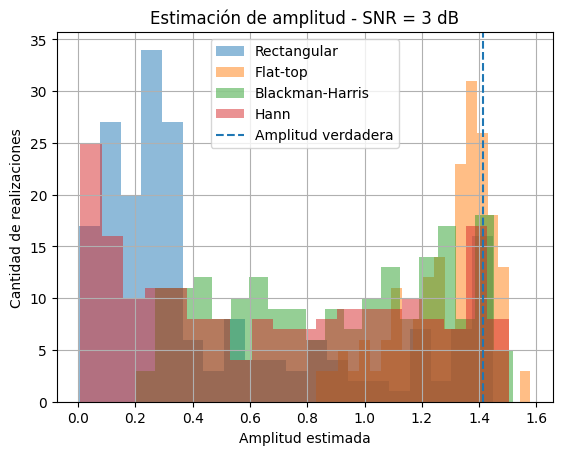

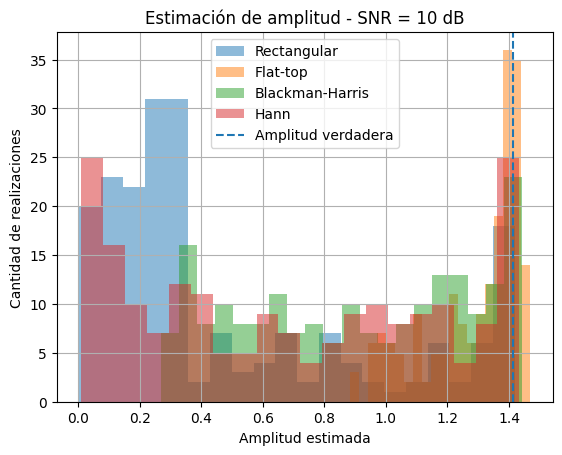

In [6]:
# -*- coding: utf-8 -*-

#%% IMPORTACION DE MODULOS

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sig


#%% PARAMETROS

N = 1000
M = 200

a0 = np.sqrt(2)

Omega0 = np.pi/2


#%% FRECUENCIAS

fr = np.random.uniform(-2, 2, M)
fr = fr.reshape((M, 1))

Omega1 = Omega0 + fr * 2*np.pi/N


#%% VECTOR DE MUESTRAS

n = np.arange(N)
n = n.reshape((1, N))


#%% VENTANAS

rect = np.ones(N)
flat = sig.windows.flattop(N)
bh = sig.windows.blackmanharris(N)
hann = sig.windows.hann(N)


#%% SNR = 3 dB

SNR = 3

Ps = a0**2/2
Pn = Ps/(10**(SNR/10))
sigma = np.sqrt(Pn)

ruido = np.random.normal(0, sigma, (M, N))

x = a0*np.sin(Omega1*n) + ruido


#%% RECTANGULAR

xw = x*rect

X = np.fft.fft(xw, axis=1)

amplitud_rect = 2*np.abs(X[:, N//4])/np.sum(rect)


#%% FLAT-TOP

xw = x*flat

X = np.fft.fft(xw, axis=1)

amplitud_flat = 2*np.abs(X[:, N//4])/np.sum(flat)


#%% BLACKMAN-HARRIS

xw = x*bh

X = np.fft.fft(xw, axis=1)

amplitud_bh = 2*np.abs(X[:, N//4])/np.sum(bh)


#%% HANN

xw = x*hann

X = np.fft.fft(xw, axis=1)

amplitud_hann = 2*np.abs(X[:, N//4])/np.sum(hann)


#%% HISTOGRAMA SNR = 3 dB

plt.figure()

plt.hist(amplitud_rect, bins=20, alpha=0.5, label="Rectangular")
plt.hist(amplitud_flat, bins=20, alpha=0.5, label="Flat-top")
plt.hist(amplitud_bh, bins=20, alpha=0.5, label="Blackman-Harris")
plt.hist(amplitud_hann, bins=20, alpha=0.5, label="Hann")

plt.axvline(a0, linestyle="--", label="Amplitud verdadera")

plt.xlabel("Amplitud estimada")
plt.ylabel("Cantidad de realizaciones")
plt.title("Estimación de amplitud - SNR = 3 dB")
plt.legend()
plt.grid()
plt.show()


#%% SNR = 10 dB

SNR = 10

Ps = a0**2/2
Pn = Ps/(10**(SNR/10))
sigma = np.sqrt(Pn)

ruido = np.random.normal(0, sigma, (M, N))

x = a0*np.sin(Omega1*n) + ruido


#%% RECTANGULAR

xw = x*rect

X = np.fft.fft(xw, axis=1)

amplitud_rect = 2*np.abs(X[:, N//4])/np.sum(rect)


#%% FLAT-TOP

xw = x*flat

X = np.fft.fft(xw, axis=1)

amplitud_flat = 2*np.abs(X[:, N//4])/np.sum(flat)


#%% BLACKMAN-HARRIS

xw = x*bh

X = np.fft.fft(xw, axis=1)

amplitud_bh = 2*np.abs(X[:, N//4])/np.sum(bh)


#%% HANN

xw = x*hann

X = np.fft.fft(xw, axis=1)

amplitud_hann = 2*np.abs(X[:, N//4])/np.sum(hann)


#%% HISTOGRAMA SNR = 10 dB

plt.figure()

plt.hist(amplitud_rect, bins=20, alpha=0.5, label="Rectangular")
plt.hist(amplitud_flat, bins=20, alpha=0.5, label="Flat-top")
plt.hist(amplitud_bh, bins=20, alpha=0.5, label="Blackman-Harris")
plt.hist(amplitud_hann, bins=20, alpha=0.5, label="Hann")

plt.axvline(a0, linestyle="--", label="Amplitud verdadera")

plt.xlabel("Amplitud estimada")
plt.ylabel("Cantidad de realizaciones")
plt.title("Estimación de amplitud - SNR = 10 dB")
plt.legend()
plt.grid()
plt.show()

 

Para un SNR de 3 dB, las estimaciones de amplitud presentan una mayor dispersión debido al mayor nivel de ruido.  

Para un SNR de 10 dB, las distribuciones presentan menor dispersión que para 3 dB, ya que el nivel de ruido es menor. Se observa también que las estimaciones se encuentran, en general, más concentradas alrededor de determinados valores.

La diferencia entre las ventanas se debe a que cada una modifica de manera diferente el espectro de la señal, afectando la estimación de amplitud.


In [7]:
#%% SESGO Y VARIANZA - AMPLITUD - SNR = 10 dB

error_rect = amplitud_rect - a0
error_flat = amplitud_flat - a0
error_bh = amplitud_bh - a0
error_hann = amplitud_hann - a0

print("SNR = 10 dB")
print()
print("Ventana             Sesgo          Varianza")
print("Rectangular:", np.mean(error_rect), np.var(error_rect))
print("Flat-top:   ", np.mean(error_flat), np.var(error_flat))
print("Blackman:   ", np.mean(error_bh), np.var(error_bh))
print("Hann:       ", np.mean(error_hann), np.var(error_hann))

SNR = 10 dB

Ventana             Sesgo          Varianza
Rectangular: -0.9341131180246662 0.19241564513756465
Flat-top:    -0.12364068960625162 0.023787196127074327
Blackman:    -0.5112256487395033 0.13642948154724002
Hann:        -0.7290187314512906 0.23001795311527054


Para un SNR de 10 dB, las cuatro ventanas presentan un sesgo negativo, por lo que tienden a subestimar la amplitud. La ventana Flat-top presenta el sesgo más cercano a cero y la menor varianza, mientras que Hann presenta la mayor varianza.
